# Arrhenius Protocol on ARC-Challenge K=4 with phi-4
## Mass-Diffusion Hypothesis Test

This notebook demonstrates the **Arrhenius inference-energy protocol** applied to `microsoft/phi-4` on ARC-Challenge (K=4 answer options).

**Hypothesis**: Reducing option count from K=10 (MMLU-Pro) to K=4 (ARC) stabilizes two-token dominance in LLM temperature-accuracy curves.

**What this notebook shows:**
- Loading pre-computed per-instance Arrhenius fits (from phi-4 API sweeps)
- Re-running the analysis pipeline: Spearman ρ(Ea, Δ), CV(log A), valid fit rate
- Generating the three paper figures: Arrhenius plots, Ea vs Δ scatter, R² histogram
- Comparing ARC-Challenge K=4 results against MMLU-Pro K=10 baseline

> **Note**: The actual LLM temperature sweeps (API calls) have already been run and results are provided as pre-computed data. This notebook re-runs the analysis and visualization only.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core scientific packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0', 'statsmodels==0.14.6')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import math
import os

import numpy as np
import matplotlib
# Use non-interactive backend only outside of notebook environments
if 'google.colab' not in sys.modules and 'ipykernel' not in sys.modules:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, binomtest
from sklearn.linear_model import LinearRegression
import statsmodels.stats.proportion as smprop

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-ce2af9-arrhenius-kinetics-of-llm-inference-acti/main/round-5/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded metadata keys: {list(data['metadata'].keys())[:8]}...")
print(f"Number of instances: {len(data['results'])}")

Loaded metadata keys: ['model_name', 'dataset', 'K', 'n_oc_scanned', 'n_oc_instances', 'smoke_test_passed', 'pilot_gate_passed', 'pilot_gate_fraction']...
Number of instances: 20


## Configuration

All tunable parameters are defined here. The defaults below are set to minimal values for a fast demo.
To reproduce the full experiment, use the commented values.

In [5]:
# Temperature grid used during the original experiment
TEMP_GRID = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
TURN_TEMPS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]

K = 4                  # Number of answer choices (ARC-Challenge)
N_BON = 16             # Best-of-N sample count

# Bootstrap iterations for R² CI computation
N_BOOT = 50            # Minimum for demo; original = 200
# N_BOOT = 200         # Full experiment value

# Bootstrap iterations for Spearman rho CI
N_BOOT_RHO = 100       # Minimum for demo; original = 500
# N_BOOT_RHO = 500     # Full experiment value

# Number of results to analyze from loaded data
N_RESULTS = len(data['results'])  # Use all loaded examples

# MMLU-Pro K=10 baseline for comparison
MMLP_BASELINE = data['metadata'].get('mmlu_pro_baseline', {
    "rho_ea_delta": 0.106, "cv_log_A": 1.093,
    "valid_fit_rate": 0.199, "median_R2": 0.848, "median_Ea": 0.351,
})

print(f"Config: N_BOOT={N_BOOT}, N_BOOT_RHO={N_BOOT_RHO}, N_RESULTS={N_RESULTS}")

Config: N_BOOT=50, N_BOOT_RHO=100, N_RESULTS=20


## Core Functions: Arrhenius Fitting

The Arrhenius model treats temperature-accuracy as an activation energy problem:

$$\log P(\text{correct}|T) = -\frac{E_a}{T} + \log A$$

Fitting `log P` vs `1/T` via linear regression yields:
- **Ea** (activation energy): how hard the instance is to "activate" at higher T
- **log A** (prefactor): baseline accessibility
- **R²**: goodness of fit

A valid fit requires R²>0.5, Ea>0, and a rising trend (P increases with T).

In [6]:
def fit_arrhenius(p_correct_by_T: dict) -> dict:
    """
    Fit Arrhenius model: log P = -Ea/T + log(A).
    Linear regression of log(P) on 1/T.
    """
    temps = sorted(float(k) for k in p_correct_by_T.keys())
    ps = [p_correct_by_T[str(T) if str(T) in p_correct_by_T else T] for T in temps]

    # Filter: need P > 0
    valid_pairs = [(T, P) for T, P in zip(temps, ps) if P > 0]
    if len(valid_pairs) < 3:
        return {"Ea": None, "log_A": None, "R2": None, "n_valid": len(valid_pairs),
                "valid_fit": False, "valid_temps": []}

    X = np.array([1.0 / T for T, _ in valid_pairs]).reshape(-1, 1)
    y = np.array([math.log(P) for _, P in valid_pairs])

    reg = LinearRegression().fit(X, y)
    Ea = -float(reg.coef_[0])      # slope = -Ea
    log_A = float(reg.intercept_)  # intercept = log(A)
    y_pred = reg.predict(X)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    R2 = float(1 - ss_res / ss_tot) if ss_tot > 0 else 0.0

    # Validity criteria
    p_by_T_float = {float(k): v for k, v in p_correct_by_T.items()}
    p_low = p_by_T_float.get(temps[0], 0.0)
    p_high = p_by_T_float.get(temps[-1], 0.0)
    valid_fit = (
        len(valid_pairs) >= 3
        and R2 > 0.5
        and Ea > 0
        and p_high > p_low  # rising trend
    )

    return {
        "Ea": Ea,
        "log_A": log_A,
        "R2": R2,
        "n_valid": len(valid_pairs),
        "valid_fit": valid_fit,
        "valid_temps": [T for T, _ in valid_pairs],
    }


def fit_alternatives(p_correct_by_T: dict) -> dict:
    """Fit alternative models: linear, exp_T, power_law."""
    temps = sorted(float(k) for k in p_correct_by_T.keys())
    ps = [p_correct_by_T[str(T) if str(T) in p_correct_by_T else T] for T in temps]
    valid_pairs = [(T, P) for T, P in zip(temps, ps) if P > 0]
    if len(valid_pairs) < 3:
        return {"linear_R2": None, "exp_T_R2": None, "power_law_R2": None}

    T_arr = np.array([T for T, _ in valid_pairs])
    P_arr = np.array([P for _, P in valid_pairs])

    results = {}
    # Linear: P = a*T + b
    try:
        reg = LinearRegression().fit(T_arr.reshape(-1, 1), P_arr)
        p_p = reg.predict(T_arr.reshape(-1, 1))
        ss_res = np.sum((P_arr - p_p) ** 2)
        ss_tot = np.sum((P_arr - P_arr.mean()) ** 2)
        results["linear_R2"] = float(1 - ss_res / ss_tot) if ss_tot > 0 else 0.0
    except Exception:
        results["linear_R2"] = None

    # Exponential: log P = a*T + b
    try:
        log_P = np.log(P_arr)
        reg = LinearRegression().fit(T_arr.reshape(-1, 1), log_P)
        log_pred = reg.predict(T_arr.reshape(-1, 1))
        ss_res = np.sum((log_P - log_pred) ** 2)
        ss_tot = np.sum((log_P - log_P.mean()) ** 2)
        results["exp_T_R2"] = float(1 - ss_res / ss_tot) if ss_tot > 0 else 0.0
    except Exception:
        results["exp_T_R2"] = None

    # Power law: log P = a * log(T) + b
    try:
        log_T = np.log(T_arr)
        log_P = np.log(P_arr)
        reg = LinearRegression().fit(log_T.reshape(-1, 1), log_P)
        log_pred = reg.predict(log_T.reshape(-1, 1))
        ss_res = np.sum((log_P - log_pred) ** 2)
        ss_tot = np.sum((log_P - log_P.mean()) ** 2)
        results["power_law_R2"] = float(1 - ss_res / ss_tot) if ss_tot > 0 else 0.0
    except Exception:
        results["power_law_R2"] = None

    return results


def bootstrap_R2(p_correct_by_T: dict, n_boot: int = N_BOOT) -> tuple:
    """Bootstrap 95% CI for R2 of Arrhenius fit."""
    temps = sorted(float(k) for k in p_correct_by_T.keys())
    ps = [p_correct_by_T[str(T) if str(T) in p_correct_by_T else T] for T in temps]
    valid_pairs = [(T, P) for T, P in zip(temps, ps) if P > 0]
    if len(valid_pairs) < 3:
        return (float("nan"), float("nan"))

    rng = np.random.default_rng(42)
    r2_boot = []
    n = len(valid_pairs)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        pairs_b = [valid_pairs[i] for i in idx]
        X_b = np.array([1.0 / T for T, _ in pairs_b]).reshape(-1, 1)
        y_b = np.array([math.log(P) for _, P in pairs_b])
        if len(set(map(tuple, X_b))) < 2:
            continue
        try:
            reg = LinearRegression().fit(X_b, y_b)
            y_pred = reg.predict(X_b)
            ss_res = np.sum((y_b - y_pred) ** 2)
            ss_tot = np.sum((y_b - y_b.mean()) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
            r2_boot.append(r2)
        except Exception:
            pass
    if not r2_boot:
        return (float("nan"), float("nan"))
    lo, hi = np.percentile(r2_boot, [2.5, 97.5])
    return float(lo), float(hi)


print("Arrhenius fitting functions loaded.")

Arrhenius fitting functions loaded.


## Utility Functions: T_thresh, T_TURN, Wilson CI, McNemar

- **T_thresh**: theoretical minimum temperature needed for BoN-N to work (from Arrhenius parameters)
- **T_TURN**: empirical temperature inflection from the entropy sweep
- **Wilson CI**: proportion confidence interval
- **McNemar**: paired accuracy test between temperature strategies

In [7]:
def compute_T_thresh(Ea: float, log_A: float, N: int) -> dict:
    """Compute T_thresh (simplified and A-corrected) for BoN-N."""
    ln_N = math.log(N)
    T_thresh_simplified = Ea / ln_N if ln_N > 0 else float("nan")
    denom = ln_N + log_A
    T_thresh_A = Ea / denom if abs(denom) > 1e-9 else float("nan")
    return {"simplified": T_thresh_simplified, "A_corrected": T_thresh_A}


def compute_T_min_emp(p_correct_by_T: dict, N: int) -> float:
    """Empirical T where P_emp(T) >= 1/N."""
    threshold = 1.0 / N
    for T in sorted(float(k) for k in p_correct_by_T.keys()):
        key = str(T) if str(T) in p_correct_by_T else T
        if p_correct_by_T[key] >= threshold:
            return T
    return None


def compute_T_TURN(entropy_by_T: dict) -> float:
    """
    TURN algorithm: find inflection in log entropy curve.
    Returns T_TURN as the temperature at the inflection point.
    """
    temps = sorted(float(k) for k in entropy_by_T.keys())
    if len(temps) < 3:
        return max(temps) + 0.1 if temps else 1.3

    log_H = np.array([math.log(max(entropy_by_T[str(T) if str(T) in entropy_by_T else T], 1e-10)) for T in temps])
    # Second differences of log_H
    d2 = np.diff(log_H, n=2)
    # First index where d2 > 0 (upward concavity = inflection)
    for i, v in enumerate(d2):
        if v > 0:
            return temps[i + 1]
    return max(temps) + 0.1


def mcnemar_exact(correct_A: list, correct_B: list) -> float:
    """Exact McNemar binomial test."""
    b = sum(1 for a, bb in zip(correct_A, correct_B) if a and not bb)
    c = sum(1 for a, bb in zip(correct_A, correct_B) if not a and bb)
    n_discordant = b + c
    if n_discordant == 0:
        return 1.0
    return float(binomtest(b, n_discordant, 0.5).pvalue)


def wilson_ci(n_success: int, n_total: int, alpha: float = 0.05) -> tuple:
    """Wilson 95% CI for a proportion."""
    if n_total == 0:
        return (0.0, 1.0)
    ci = smprop.proportion_confint(n_success, n_total, alpha=alpha, method="wilson")
    return float(ci[0]), float(ci[1])


print("Utility functions loaded.")

Utility functions loaded.


## Analysis Pipeline

The `analyze_results` function computes all aggregate metrics from per-instance results:

| Metric | Description | MMLU-Pro K=10 baseline |
|--------|-------------|------------------------|
| valid_fit_rate | Fraction with R²>0.5, Ea>0, rising | 19.9% |
| median_R² | Median Arrhenius R² | 0.848 |
| median_Ea | Median activation energy | 0.351 |
| ρ(Ea, Δ) | Spearman correlation Ea vs logit gap | 0.106 |
| CV(log A) | Coefficient of variation of prefactor | 1.093 |

**Verdict criteria**: CONFIRMS if ρ(Ea,Δ)>0.6 AND CV(log A)<0.4

In [8]:
def analyze_results(results: list) -> dict:
    """Compute all analysis metrics from per-instance results."""
    if not results:
        return {}

    valid = [r for r in results if r.get("is_valid_fit") and r.get("Ea") is not None]
    all_with_r2 = [r for r in results if r.get("R2") is not None]

    n_valid = len(valid)
    n_total = len(results)
    valid_fit_rate = n_valid / n_total if n_total > 0 else 0.0

    # Median R2 across all instances with >=3 non-zero P values
    r2_all = [r["R2"] for r in all_with_r2 if r["R2"] is not None]
    median_R2 = float(np.median(r2_all)) if r2_all else float("nan")

    # Bootstrap R2 CI
    if valid:
        r2_valid = [r["R2"] for r in valid]
        r2_lo, r2_hi = float(np.percentile(r2_valid, 2.5)), float(np.percentile(r2_valid, 97.5))
    else:
        r2_lo, r2_hi = float("nan"), float("nan")

    # Arrhenius parameters for valid fits
    Ea_arr = [r["Ea"] for r in valid]
    logA_arr = [r["log_A"] for r in valid]
    median_Ea = float(np.median(Ea_arr)) if Ea_arr else float("nan")
    logA_mean = float(np.mean(logA_arr)) if logA_arr else float("nan")
    logA_std = float(np.std(logA_arr)) if logA_arr else float("nan")
    cv_log_A = logA_std / abs(logA_mean) if (logA_arr and abs(logA_mean) > 1e-9) else float("nan")

    # Spearman rho(Ea, Delta) with bootstrap CI
    delta_arr = [r["Delta"] for r in valid if r.get("Delta") is not None and not math.isnan(r.get("Delta", float("nan")))]
    Ea_for_delta = [r["Ea"] for r in valid if r.get("Delta") is not None and not math.isnan(r.get("Delta", float("nan")))]
    rho_ea_delta = float("nan")
    rho_ea_delta_p = float("nan")
    rho_ea_delta_ci = (float("nan"), float("nan"))
    if len(Ea_for_delta) >= 5:
        rho_res = spearmanr(Ea_for_delta, delta_arr)
        rho_ea_delta = float(rho_res.statistic)
        rho_ea_delta_p = float(rho_res.pvalue)
        # Bootstrap CI
        rng = np.random.default_rng(42)
        n = len(Ea_for_delta)
        boot_rhos = []
        for _ in range(N_BOOT_RHO):
            idx = rng.integers(0, n, size=n)
            Eb = [Ea_for_delta[i] for i in idx]
            Db = [delta_arr[i] for i in idx]
            try:
                boot_rhos.append(spearmanr(Eb, Db).statistic)
            except Exception:
                pass
        if boot_rhos:
            rho_ea_delta_ci = (float(np.percentile(boot_rhos, 2.5)),
                               float(np.percentile(boot_rhos, 97.5)))

    # T_thresh validation (Step C)
    T_thresh_by_N = {}
    for N in [4, 8, 16, 32]:
        is_lb = []
        T_thresh_list = []
        for r in valid:
            Ea = r["Ea"]
            log_A = r.get("log_A", 0.0) or 0.0
            if Ea is None:
                continue
            thresh = compute_T_thresh(Ea, log_A, N)
            T_s = thresh["simplified"]
            p_by_T = {float(k): v for k, v in r["p_correct_by_T"].items()}
            T_min_emp = compute_T_min_emp(p_by_T, N)
            if T_min_emp is not None and not math.isnan(T_s):
                is_lb.append(T_s < T_min_emp)
                T_thresh_list.append(T_s)

        n_lb = sum(1 for x in is_lb if x)
        n_tot = len(is_lb)
        frac = n_lb / n_tot if n_tot > 0 else 0.0
        ci_lo, ci_hi = wilson_ci(n_lb, n_tot)
        theorem_applies = N > K  # Theorem 6 applies when N > K=4
        median_T_thresh_N = float(np.median(T_thresh_list)) if T_thresh_list else float("nan")

        T_thresh_by_N[N] = {
            "n_total": n_tot,
            "fraction_simplified_is_lower_bound": frac,
            "wilson_ci_low": ci_lo,
            "wilson_ci_high": ci_hi,
            "theorem6_applies": theorem_applies,
            "median_T_thresh": median_T_thresh_N,
        }

    # T_TURN analysis
    T_TURN_arr = [r.get("T_TURN_emp", 1.3) for r in valid]
    T_thresh_N16_arr = []
    for r in valid:
        Ea = r["Ea"]
        log_A = r.get("log_A", 0.0) or 0.0
        if Ea is not None and Ea > 0:
            T_thresh_N16_arr.append(compute_T_thresh(Ea, log_A, 16)["simplified"])
    median_T_TURN_emp = float(np.median(T_TURN_arr)) if T_TURN_arr else float("nan")
    median_T_thresh_N16 = float(np.median(T_thresh_N16_arr)) if T_thresh_N16_arr else float("nan")

    frac_below_T_TURN = 0.0
    if T_thresh_N16_arr and T_TURN_arr:
        pairs = list(zip(T_thresh_N16_arr, T_TURN_arr[:len(T_thresh_N16_arr)]))
        frac_below_T_TURN = sum(1 for t_th, t_turn in pairs if t_th < t_turn) / len(pairs)

    # rho(Ea, T_pref)
    T_pref_arr = [r.get("T_pref", float("nan")) for r in valid]
    Ea_tpref = [r["Ea"] for r in valid]
    rho_ea_tpref = float("nan")
    rho_ea_tpref_p = float("nan")
    valid_pairs_tpref = [(e, t) for e, t in zip(Ea_tpref, T_pref_arr)
                         if t is not None and not math.isnan(float(t)) and e is not None]
    if len(valid_pairs_tpref) >= 5:
        e_arr_tp = [x[0] for x in valid_pairs_tpref]
        t_arr_tp = [x[1] for x in valid_pairs_tpref]
        rho_res_tp = spearmanr(e_arr_tp, t_arr_tp)
        rho_ea_tpref = float(rho_res_tp.statistic)
        rho_ea_tpref_p = float(rho_res_tp.pvalue)

    # Two-token dominance
    two_token_dominance_confirmed = (rho_ea_delta > 0.6 and cv_log_A < 0.4
                                     if not math.isnan(rho_ea_delta) else False)

    # Verdict
    if math.isnan(rho_ea_delta):
        verdict = "UNDERPOWERED"
        rationale = "Insufficient valid fits for correlation analysis."
    elif rho_ea_delta > 0.6 and cv_log_A < 0.4:
        verdict = "CONFIRMS"
        rationale = (f"K=4 shows rho(Ea,Delta)={rho_ea_delta:.3f}>0.6 and "
                     f"CV(log A)={cv_log_A:.3f}<0.4, confirming two-token dominance "
                     f"hypothesis vs MMLU-Pro K=10 baseline.")
    elif rho_ea_delta < 0.3:
        verdict = "DISCONFIRMS"
        rationale = (f"K=4 shows rho(Ea,Delta)={rho_ea_delta:.3f}<0.3, "
                     f"not supporting two-token dominance. Mass-diffusion hypothesis "
                     f"not confirmed by K reduction alone.")
    else:
        verdict = "UNDERPOWERED"
        rationale = (f"Intermediate rho={rho_ea_delta:.3f}; need more instances "
                     f"for definitive verdict. CV(log A)={cv_log_A:.3f}.")

    comparison = {
        "arc_rho_ea_delta": rho_ea_delta,
        "arc_cv_log_A": cv_log_A,
        "arc_valid_fit_rate": valid_fit_rate,
        "arc_median_R2": median_R2,
        "arc_median_Ea": median_Ea,
        "mmlu_rho_ea_delta": 0.106,
        "mmlu_cv_log_A": 1.093,
        "mmlu_valid_fit_rate": 0.199,
        "mmlu_median_R2": 0.848,
        "mmlu_median_Ea": 0.351,
        "rho_improved": (rho_ea_delta > 0.106) if not math.isnan(rho_ea_delta) else None,
        "cv_improved": (cv_log_A < 1.093) if not math.isnan(cv_log_A) else None,
        "fit_rate_improved": (valid_fit_rate > 0.199),
        "verdict": verdict,
        "verdict_rationale": rationale,
    }

    return {
        "n_valid_fits": n_valid,
        "valid_fit_rate": valid_fit_rate,
        "median_R2": median_R2,
        "bootstrap_R2_ci_low": r2_lo,
        "bootstrap_R2_ci_high": r2_hi,
        "median_Ea": median_Ea,
        "logA_mean": logA_mean,
        "logA_std": logA_std,
        "cv_log_A": cv_log_A,
        "rho_ea_delta": rho_ea_delta,
        "rho_ea_delta_p": rho_ea_delta_p,
        "rho_ea_delta_ci_low": rho_ea_delta_ci[0],
        "rho_ea_delta_ci_high": rho_ea_delta_ci[1],
        "two_token_dominance_confirmed": two_token_dominance_confirmed,
        "step6_T_thresh_validation": {
            "by_N": {str(N): T_thresh_by_N[N] for N in [4, 8, 16, 32]},
            "fraction_T_thresh_below_T_TURN": frac_below_T_TURN,
            "median_T_thresh_N16": median_T_thresh_N16,
            "median_T_TURN_emp": median_T_TURN_emp,
        },
        "rho_ea_tpref": rho_ea_tpref,
        "rho_ea_tpref_p": rho_ea_tpref_p,
        "comparison_vs_mmlu_pro": comparison,
    }


print("analyze_results() function loaded.")

analyze_results() function loaded.


## Run Analysis on Loaded Data

We now run the analysis pipeline on the pre-computed per-instance results from the data file.

In [9]:
# Use the first N_RESULTS instances from the loaded data
results = data['results'][:N_RESULTS]

print(f"Analyzing {len(results)} instances...")
analysis = analyze_results(results)

print(f"\nAnalysis complete:")
print(f"  Valid fits: {analysis['n_valid_fits']}/{len(results)} ({analysis['valid_fit_rate']*100:.1f}%)")
print(f"  Median R²: {analysis['median_R2']:.4f}")
print(f"  Median Ea: {analysis['median_Ea']:.4f}")
print(f"  rho(Ea, Delta): {analysis['rho_ea_delta']:.4f}  (p={analysis['rho_ea_delta_p']:.2e})")
print(f"  CV(log A): {analysis['cv_log_A']:.4f}")
print(f"\nVerdict: {analysis['comparison_vs_mmlu_pro']['verdict']}")
print(f"Rationale: {analysis['comparison_vs_mmlu_pro']['verdict_rationale']}")

Analyzing 20 instances...

Analysis complete:
  Valid fits: 15/20 (75.0%)
  Median R²: 0.8928
  Median Ea: 0.3430
  rho(Ea, Delta): 0.9696  (p=2.52e-09)
  CV(log A): 1.3344

Verdict: UNDERPOWERED
Rationale: Intermediate rho=0.970; need more instances for definitive verdict. CV(log A)=1.334.


## Generate Figures

Three figures are generated:
1. **Arrhenius plots** for representative instances: log P(correct) vs 1/T with regression line
2. **Ea vs Δ scatter**: tests two-token dominance (Spearman ρ)
3. **R² distribution histogram**: compares ARC K=4 vs MMLU-Pro K=10 baseline

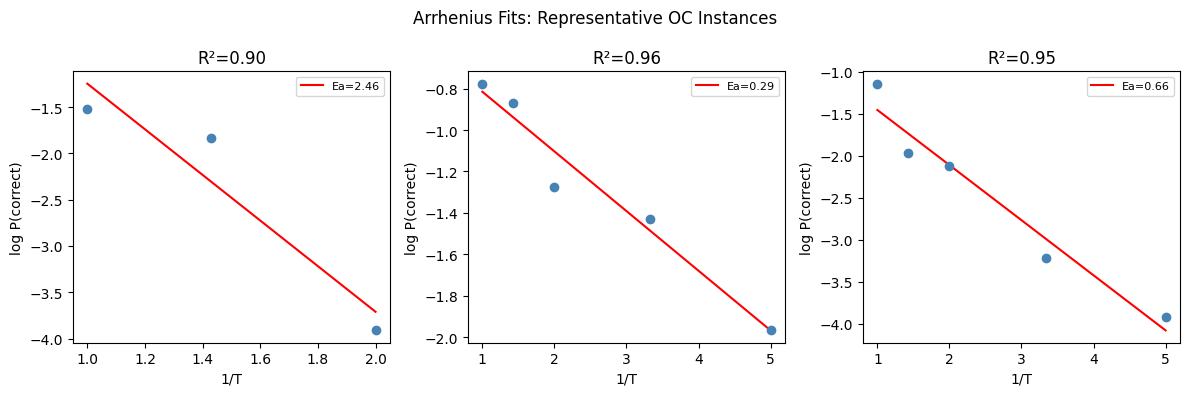

Figure 1 saved: figure1_arrhenius_plots.png


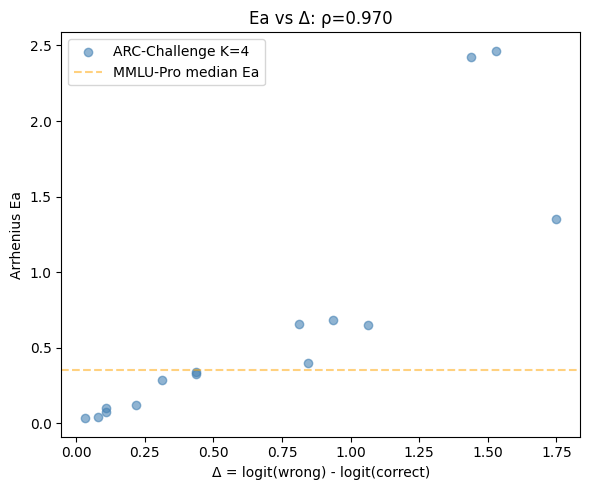

Figure 2 saved: figure2_ea_vs_delta.png


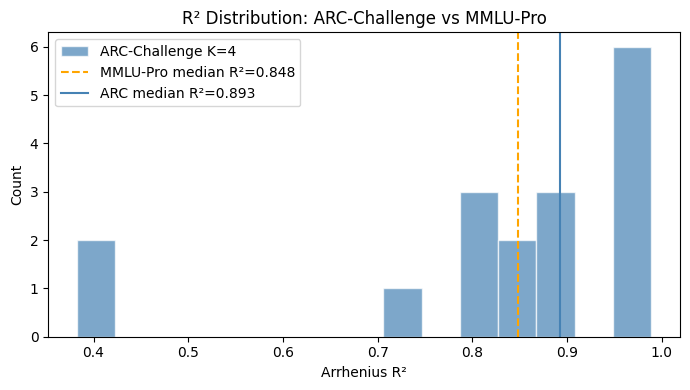

Figure 3 saved: figure3_r2_distribution.png

Total figures generated: 3


In [10]:
def generate_figures(results: list, analysis: dict):
    """Generate 3 matplotlib figures."""
    valid = [r for r in results if r.get("is_valid_fit") and r.get("Ea") is not None]
    figure_paths = []

    # Figure 1: Arrhenius plots for 3 representative instances
    n_show = min(3, len(valid))
    if n_show > 0:
        fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
        axes_list = [axes] if n_show == 1 else list(axes)

        for ax, inst in zip(axes_list, valid[:3]):
            p_by_T = {float(k): v for k, v in inst["p_correct_by_T"].items()}
            temps = sorted(p_by_T.keys())
            ps = [p_by_T[T] for T in temps]
            valid_pairs = [(T, P) for T, P in zip(temps, ps) if P > 0]
            if len(valid_pairs) >= 2:
                inv_T = [1.0 / T for T, _ in valid_pairs]
                log_P = [math.log(P) for _, P in valid_pairs]
                ax.scatter(inv_T, log_P, color="steelblue", zorder=5)
                # Regression line
                x_fit = np.linspace(min(inv_T), max(inv_T), 50)
                Ea = inst["Ea"]
                log_A = inst["log_A"]
                y_fit = [-Ea * x + log_A for x in x_fit]
                ax.plot(x_fit, y_fit, "r-", label=f"Ea={Ea:.2f}")
                ax.set_xlabel("1/T")
                ax.set_ylabel("log P(correct)")
                ax.set_title(f"R²={inst['R2']:.2f}")
                ax.legend(fontsize=8)

        plt.suptitle("Arrhenius Fits: Representative OC Instances", fontsize=12)
        plt.tight_layout()
        fig1_path = "figure1_arrhenius_plots.png"
        plt.savefig(fig1_path, dpi=100, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        figure_paths.append(fig1_path)
        print(f"Figure 1 saved: {fig1_path}")

    # Figure 2: Ea vs Delta scatter
    if valid:
        Ea_arr = [r["Ea"] for r in valid if r.get("Delta") is not None and not math.isnan(r.get("Delta", float("nan")))]
        delta_arr = [r["Delta"] for r in valid if r.get("Delta") is not None and not math.isnan(r.get("Delta", float("nan")))]
        if Ea_arr and delta_arr:
            fig, ax = plt.subplots(figsize=(6, 5))
            ax.scatter(delta_arr, Ea_arr, alpha=0.6, color="steelblue", label="ARC-Challenge K=4")
            rho = analysis.get("rho_ea_delta", float("nan"))
            ax.set_xlabel("Δ = logit(wrong) - logit(correct)")
            ax.set_ylabel("Arrhenius Ea")
            ax.set_title(f"Ea vs Δ: ρ={rho:.3f}" if not math.isnan(rho) else "Ea vs Δ")
            # Add MMLU-Pro reference
            ax.axhline(y=0.351, color="orange", linestyle="--", alpha=0.5, label="MMLU-Pro median Ea")
            ax.legend()
            plt.tight_layout()
            fig2_path = "figure2_ea_vs_delta.png"
            plt.savefig(fig2_path, dpi=100, bbox_inches="tight")
            plt.show()
            plt.close(fig)
            figure_paths.append(fig2_path)
            print(f"Figure 2 saved: {fig2_path}")

    # Figure 3: R2 distribution histogram
    if results:
        r2_vals = [r["R2"] for r in results if r.get("R2") is not None]
        if r2_vals:
            fig, ax = plt.subplots(figsize=(7, 4))
            ax.hist(r2_vals, bins=15, alpha=0.7, color="steelblue",
                    edgecolor="white", label="ARC-Challenge K=4")
            ax.axvline(x=0.848, color="orange", linestyle="--",
                       label="MMLU-Pro median R²=0.848")
            ax.axvline(x=np.median(r2_vals), color="steelblue", linestyle="-",
                       label=f"ARC median R²={np.median(r2_vals):.3f}")
            ax.set_xlabel("Arrhenius R²")
            ax.set_ylabel("Count")
            ax.set_title("R² Distribution: ARC-Challenge vs MMLU-Pro")
            ax.legend()
            plt.tight_layout()
            fig3_path = "figure3_r2_distribution.png"
            plt.savefig(fig3_path, dpi=100, bbox_inches="tight")
            plt.show()
            plt.close(fig)
            figure_paths.append(fig3_path)
            print(f"Figure 3 saved: {fig3_path}")

    return figure_paths


figure_paths = generate_figures(results, analysis)
print(f"\nTotal figures generated: {len(figure_paths)}")

## Results Summary

Final comparison of ARC-Challenge K=4 vs MMLU-Pro K=10 baseline.

In [11]:
comp = analysis['comparison_vs_mmlu_pro']
thresh_val = analysis['step6_T_thresh_validation']

print("=" * 60)
print("ARRHENIUS PROTOCOL RESULTS: ARC-Challenge K=4 vs MMLU-Pro K=10")
print("=" * 60)
print(f"{'Metric':<35} {'ARC K=4':>10} {'MMLU K=10':>10} {'Better?':>8}")
print("-" * 65)

def fmt(v):
    if v is None or (isinstance(v, float) and math.isnan(v)):
        return "N/A"
    return f"{v:.4f}"

rows = [
    ("Valid fit rate",         comp['arc_valid_fit_rate'],  comp['mmlu_valid_fit_rate'],  comp.get('fit_rate_improved')),
    ("Median R²",              comp['arc_median_R2'],       comp['mmlu_median_R2'],        None),
    ("Median Ea",              comp['arc_median_Ea'],       comp['mmlu_median_Ea'],        None),
    ("ρ(Ea, Δ) [two-token]",  comp['arc_rho_ea_delta'],    comp['mmlu_rho_ea_delta'],    comp.get('rho_improved')),
    ("CV(log A) [universality]",comp['arc_cv_log_A'],       comp['mmlu_cv_log_A'],        comp.get('cv_improved')),
]

for name, arc_val, mmlu_val, better in rows:
    b_str = ("✓" if better else "✗") if better is not None else ""
    print(f"{name:<35} {fmt(arc_val):>10} {fmt(mmlu_val):>10} {b_str:>8}")

print("-" * 65)
print(f"\nBootstrap 95% CI for ρ(Ea,Δ): [{fmt(analysis['rho_ea_delta_ci_low'])}, {fmt(analysis['rho_ea_delta_ci_high'])}]")
print(f"Bootstrap 95% CI for R² (valid): [{fmt(analysis['bootstrap_R2_ci_low'])}, {fmt(analysis['bootstrap_R2_ci_high'])}]")
print(f"\nT_thresh validation (N=16): {fmt(thresh_val['by_N']['16']['fraction_simplified_is_lower_bound'])} fraction is lower bound")
print(f"  Theorem 6 applies (N>K=4): {thresh_val['by_N']['16']['theorem6_applies']}")

print(f"\n{'='*60}")
print(f"VERDICT: {comp['verdict']}")
print(f"Rationale: {comp['verdict_rationale']}")
print(f"{'='*60}")

# Also show the pre-computed verdict from the original full run
orig_comp = data['metadata'].get('comparison_vs_mmlu_pro', {})
print(f"\nOriginal full-run verdict: {orig_comp.get('verdict', 'N/A')}")
print(f"(Full run had {data['metadata'].get('n_valid_fits', 'N/A')} valid fits from {data['metadata'].get('n_oc_instances', 'N/A')} OC instances)")

ARRHENIUS PROTOCOL RESULTS: ARC-Challenge K=4 vs MMLU-Pro K=10
Metric                                 ARC K=4  MMLU K=10  Better?
-----------------------------------------------------------------
Valid fit rate                          0.7500     0.1990        ✓
Median R²                               0.8928     0.8480         
Median Ea                               0.3430     0.3510         
ρ(Ea, Δ) [two-token]                    0.9696     0.1060        ✓
CV(log A) [universality]                1.3344     1.0930        ✗
-----------------------------------------------------------------

Bootstrap 95% CI for ρ(Ea,Δ): [0.8396, 0.9964]
Bootstrap 95% CI for R² (valid): [0.7696, 0.9883]

T_thresh validation (N=16): 0.8667 fraction is lower bound
  Theorem 6 applies (N>K=4): True

VERDICT: UNDERPOWERED
Rationale: Intermediate rho=0.970; need more instances for definitive verdict. CV(log A)=1.334.

Original full-run verdict: UNDERPOWERED
(Full run had 27 valid fits from 50 OC instances)
